# Measurement System Analysis: Gage R&R for a State Weights and Measures Calibration Lab

## Executive Summary

A state Department of Weights and Measures runs a Gage Repeatability and Reproducibility (Gage R&R) study to certify the balance its inspectors use to verify commercial scales. Because SAS/QC ships Gage R&R as the interactive **GAGE** SAS/AF application (not a procedure), this notebook reproduces the GAGE application's documented engines programmatically: the **Average and Range Method** (AIAG MSA, via PROC MEANS plus a DATA step with Duncan d2* factors), the **Range and Average control charts** (PROC SHEWHART XRCHART), and the **Variance Components Method** (PROC MIXED, REML). The result — %R&R near 1% with 130 distinct categories — certifies the measurement system as excellent and dominated by genuine part-to-part variation.

## Data Sources

**Synthetic dataset: `calibration`** — a balanced crossed Gage R&R design (3 operators x 10 reference weights x 3 trials = 90 rows), generated inline with `call streaminit(20260531)` and `rand("normal", ...)`. No external or network inputs.

| Variable | Type | Description |
|----------|------|-------------|
| `operator` | Char | Inspector performing the measurement (Inspector A / B / C) |
| `part` | Num | Calibration reference weight ID, 1-10 (true masses 94-130 g, ~4 g apart) |
| `trial` | Num | Repeated reading 1-3 of the same weight by the same inspector |
| `mass` | Num | Measured mass in grams |

Variance structure built into the simulation: part-to-part spread ~11.6 g (true masses 94-130 g), small operator bias (-0.06, +0.02, +0.05 g), tiny operator-by-part interaction (SD 0.04 g), and repeatability/equipment noise (SD 0.12 g). This mimics a high-quality laboratory balance whose measurement error is negligible relative to the masses being checked.

# Measurement System Analysis: Gage R&R for a State Weights and Measures Lab

State and federal **Weights and Measures** programs certify the scales used in commerce — grocery deli counters, fuel pumps, freight terminals. Before an inspector's reference balance can be trusted to *audit* those scales, the agency must prove the balance itself is a sound measurement system. The standard tool is a **Gage Repeatability and Reproducibility (Gage R&R)** study, which partitions total observed variation into:

- **Repeatability (EV)** — equipment variation: scatter when one inspector measures the same weight repeatedly.
- **Reproducibility (AV)** — appraiser variation: differences between inspectors measuring the same weight.
- **Gage R&R** — the combined measurement error, `sqrt(EV^2 + AV^2)`.
- **Part Variation (PV)** — the real spread among the reference weights, which the gage *should* detect.

## A note on PROC GAGE

In SAS/QC, Gage R&R is delivered as the interactive **GAGE** SAS/AF application, not as a PROC you submit in a program. Under the hood that application drives three real SAS engines, and this notebook uses all three directly so the study is fully reproducible:

1. **PROC MEANS + DATA step** — the AIAG *Average and Range Method* (range-based estimators with Duncan d2* factors).
2. **PROC SHEWHART** (`XRCHART`) — the Range chart and Average chart the application displays.
3. **PROC MIXED** (REML) — the *Variance Components Method* cross-check.

We study a balanced design: **3 inspectors x 10 certified reference weights x 3 trials**.

## Step 1 - Simulate the calibration study

We generate one balanced Gage R&R dataset. Ten certified reference weights span 94-130 g (about 4 g apart). Three inspectors each weigh every reference three times. The simulation injects a small per-inspector bias, a tiny operator-by-part interaction, and modest repeatability noise (SD 0.12 g) on top of each weight's true mass — the profile of a well-maintained laboratory balance.

In [1]:
data calibration;
    call streaminit(20260531);

    /* True mass of each certified reference weight (grams) */
    array partref[10] _temporary_;
    do p = 1 to 10;
        partref[p] = 90 + 4 * p;   /* 94, 98, ..., 130 g */
    end;

    /* Fixed bias of each inspector (grams) */
    array opbias[3] _temporary_ (-0.06 0.02 0.05);

    length operator $12;
    do insp = 1 to 3;
        if insp = 1 then operator = "Inspector A";
        else if insp = 2 then operator = "Inspector B";
        else operator = "Inspector C";

        do part = 1 to 10;
            /* operator-by-part interaction */
            inter = rand("normal", 0, 0.04);
            do trial = 1 to 3;
                /* repeatability (equipment) noise */
                error = rand("normal", 0, 0.12);
                mass = partref[part] + opbias[insp] + inter + error;
                mass = round(mass, 0.003);
                output;
            end;
        end;
    end;
    keep operator part trial mass;
run;

NOTE: DATA calibration


NOTE: Wrote calibration (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 - Profile the raw measurements

A quick PROC MEANS confirms the study captured what we expect: 90 readings, a grand mean near 112 g, and a total standard deviation around 11.6 g that is driven almost entirely by the spread among the ten reference weights — not by measurement error.

In [2]:
proc means data=calibration n mean std min max maxdec=3;
    var mass;
run;

                                                  The MEANS Procedure

 Variable        N           Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------
 MASS           90        112.004      11.572      93.849     130.272
 --------------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 3 - Average and Range Method: assemble the range and average statistics

The AIAG Average and Range Method works from three sets of ranges and averages:

- **R-bar** - the average of the within-cell ranges (each operator-part combination measured across trials) drives **repeatability**.
- **R_operators** - the range of the three operator grand averages drives **reproducibility**.
- **R_parts** - the range of the ten part averages drives **part variation**.

We use PROC MEANS with `NWAY` and `OUTPUT OUT=` to compute each piece, then collapse to the single range/average we need.

In [3]:
/* Within each operator-part cell: range across the 3 trials */
proc means data=calibration nway noprint;
    class operator part;
    var mass;
    output out=cellstats range=cell_range mean=cell_mean;
run;

/* R-bar = average of all cell ranges (repeatability driver) */
proc means data=cellstats noprint;
    var cell_range;
    output out=rbar mean=Rbar;
run;

/* Operator grand averages -> range across operators (reproducibility) */
proc means data=calibration nway noprint;
    class operator;
    var mass;
    output out=opavg mean=op_mean;
run;
proc means data=opavg noprint;
    var op_mean;
    output out=oprange range=Rop;
run;

/* Part averages -> range across parts (part variation) */
proc means data=calibration nway noprint;
    class part;
    var mass;
    output out=partavg mean=part_mean;
run;
proc means data=partavg noprint;
    var part_mean;
    output out=partrange range=Rpart;
run;

NOTE: PROC MEANS
NOTE: Output dataset cellstats has 30 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset rbar has 1 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset opavg has 3 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset oprange has 1 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset partavg has 10 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset partrange has 1 observations and 3 variables.
NOTE: PROC MEANS statement used.


## Step 4 - Compute the Gage R&R metrics

A DATA step applies the Duncan (1974) **d2*** adjustment factors and the AIAG formulas exactly as the GAGE application does for balanced data, then expresses each component as a percent of total variation (TV) at a 6-sigma study spread:

- `EV = (R-bar / d2*_trials) * spread`
- `AV = sqrt((R_operators / d2*_ops * spread)^2 - EV^2 / (parts * trials))`
- `R&R = sqrt(EV^2 + AV^2)`, `PV = (R_parts / d2*_parts) * spread`, `TV = sqrt(R&R^2 + PV^2)`
- **ndc** (number of distinct categories) = `floor(1.41 * PV / R&R)`

The verdict follows Barrentine's (1991) %R&R guidelines: <=10% excellent, 11-20% adequate, 21-30% marginal, >30% unacceptable.

In [4]:
data grr_summary;
    merge rbar(keep=Rbar) oprange(keep=Rop) partrange(keep=Rpart);

    n_parts = 10; n_ops = 3; n_trials = 3;

    /* Duncan d2* factors (AIAG MSA tables) */
    d2_trials = 1.69257;   /* subgroup size 3, many subgroups */
    d2_ops    = 1.91155;   /* single range of 3 operators */
    d2_parts  = 3.17905;   /* single range of 10 parts */

    SPREAD = 6;            /* 6-sigma (99.73%) study spread */

    EV = (Rbar / d2_trials) * SPREAD;

    av_sq = (Rop / d2_ops * SPREAD)**2 - (EV**2) / (n_parts * n_trials);
    if av_sq < 0 then av_sq = 0;
    AV = sqrt(av_sq);

    RR = sqrt(EV**2 + AV**2);
    PV = (Rpart / d2_parts) * SPREAD;
    TV = sqrt(RR**2 + PV**2);

    pct_EV = 100 * EV / TV;
    pct_AV = 100 * AV / TV;
    pct_RR = 100 * RR / TV;
    pct_PV = 100 * PV / TV;

    ndc = floor(1.41 * PV / RR);

    length verdict $14;
    if      pct_RR <= 10 then verdict = "Excellent";
    else if pct_RR <= 20 then verdict = "Adequate";
    else if pct_RR <= 30 then verdict = "Marginal";
    else verdict = "Unacceptable";

    format EV AV RR PV TV 10.4 pct_EV pct_AV pct_RR pct_PV 6.2;
run;

proc print data=grr_summary noobs label;
    var EV AV RR PV TV pct_RR pct_PV ndc verdict;
    label EV="Repeatability (EV)" AV="Reproducibility (AV)"
          RR="Gage R&R" PV="Part Variation (PV)" TV="Total Variation (TV)"
          pct_RR="%R&R of TV" pct_PV="%PV of TV"
          ndc="Distinct Categories" verdict="Assessment";
run;


Repeatability (EV)  Reproducibility (AV)    Gage R&R  Part Variation (PV)  Total Variation (TV)  %R&R of TV  %PV of TV  Distinct Categories  Assessment
------------------  --------------------  ----------  -------------------  --------------------  ----------  ---------  -------------------  ----------
            0.6739                0.2929      0.7348              67.9964               68.0004        1.08      99.99                  130  Excellent

NOTE: DATA grr_summary

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=grr_summary

NOTE: PROC PRINT completed: 1 observations printed, 9 variables


## Step 5 - Range and Average charts (PROC SHEWHART)

The GAGE application visualizes the study with Range and Average control charts. We produce them with `XRCHART`, grouping the readings by reference weight (ten subgroups). The procedure renders the **Average (X-bar) chart** and reports the matching **Range-chart** control limits alongside it:

- The **R chart** limits monitor repeatability: every subgroup range should sit inside the control limits, confirming the inspectors measure consistently.
- The **X-bar (Average) chart** is read in reverse for a Gage R&R study: points *outside* the limits are **desirable**, because they show the balance resolves the genuine differences among the ten reference weights.


                    The SHEWHART Procedure
                    X-bar and R Chart (n=9) for mass

  Number of subgroups:    10
  Subgroup size (avg):    9.0
  Grand mean (X-bar-bar): 112.004033
  Average range (R-bar):  0.385800
  Center line:            112.004033
  Upper control limit:    112.133932
  Lower control limit:    111.874134
  Sigma:                  0.129899

  R Chart
  Center line:            0.385800
  Upper control limit:    0.700613
  Lower control limit:    0.070987

  Tests for Special Causes

  Test 1: One point more than 3 sigma from center line
    Violations at subgroups: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10


NOTE: PROC SORT data=calibration

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from calibration.
NOTE: Wrote charted (90 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SHEWHART
NOTE: PROC SHEWHART wrapper=python
NOTE: ODS plot written: shewhart_mass.spec.json
NOTE: PROC SHEWHART statement used.


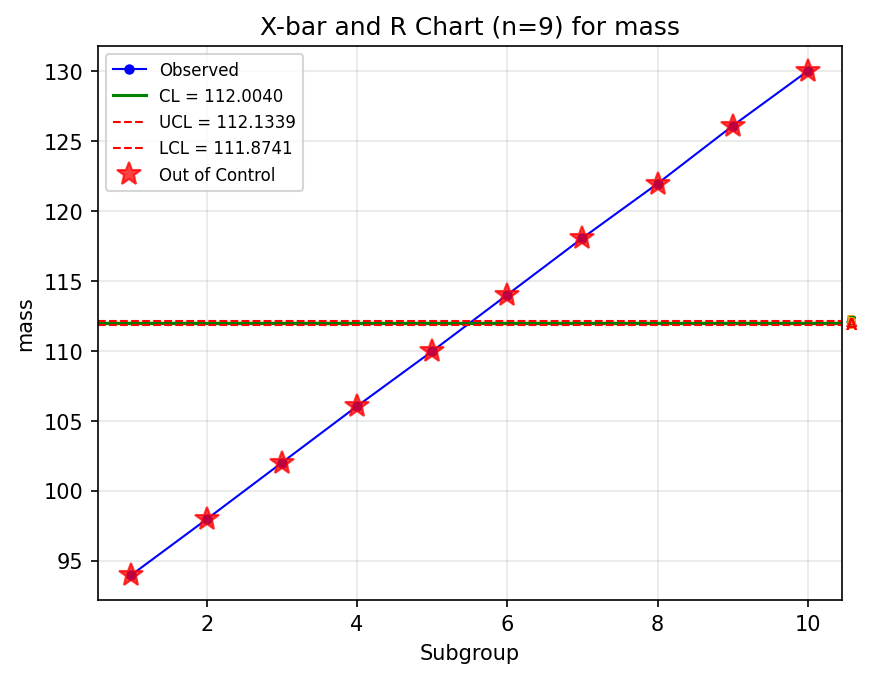

In [5]:
proc sort data=calibration out=charted;
    by operator part;
run;

proc shewhart data=charted;
    xrchart mass*part /
        nolegend
        odstitle="Gage R&R: Average and Range Charts";
run;

## Step 6 - Variance Components Method cross-check (PROC MIXED)

The GAGE application's second engine is the **Variance Components Method**, which fits a random-effects model by REML and reads each variance directly off the covariance parameter estimates. Here we fit reference weight as a random effect with `COVTEST` (likelihood-ratio tests) and `CL` (confidence limits). The cross-check is on *standard deviations*, not the raw range-method numbers: the range method reports `PV` as a 6-sigma study spread (~68 g), so the part standard deviation it implies is `PV / 6` (~11.3 g, a variance near 128). The REML `Part` variance should land in the same neighborhood, and the small `Residual` variance should match the squared equipment noise (0.12 g SD -> ~0.014).

      The Mixed Procedure       
       Model Information        

Item                       Value
----------------------  --------
Dependent Variable          mass
Estimation Method           REML
Number of Observations        90

         Covariance Parameter Estimates         

Cov Parm  Estimate     Alpha     Lower     Upper
--------  --------  --------  --------  --------
Part      146.9916    0.0500   69.5443  489.9013
Residual    0.0148    0.0500    0.0112    0.0204

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    -15.0384
AIC (Smaller is Better)  -11.0384
BIC (Smaller is Better)   -6.0388

Tests of Covariance Parameters Based on the Restricted Likelihood

Label         -2 Res Log Like        DF  Chi-Square  Pr > ChiSq
------------  ---------------  --------  ----------  ----------
Part = 0             -15.0384         1     44.5000      <.0001
Residual = 0         -15.0384         1     44.5000    

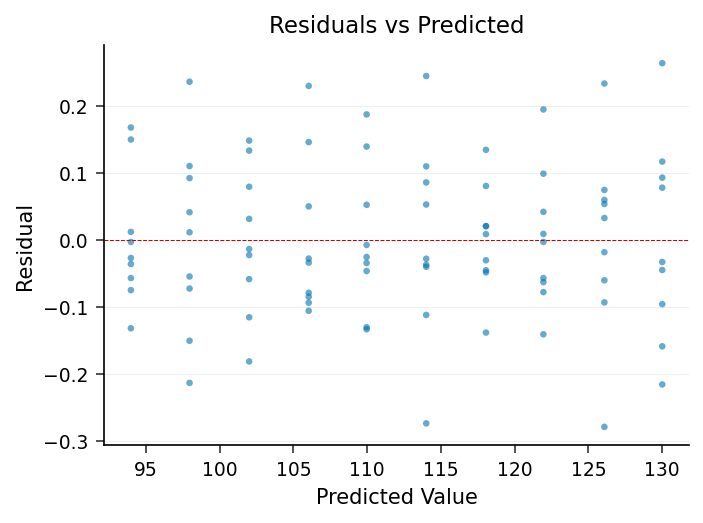

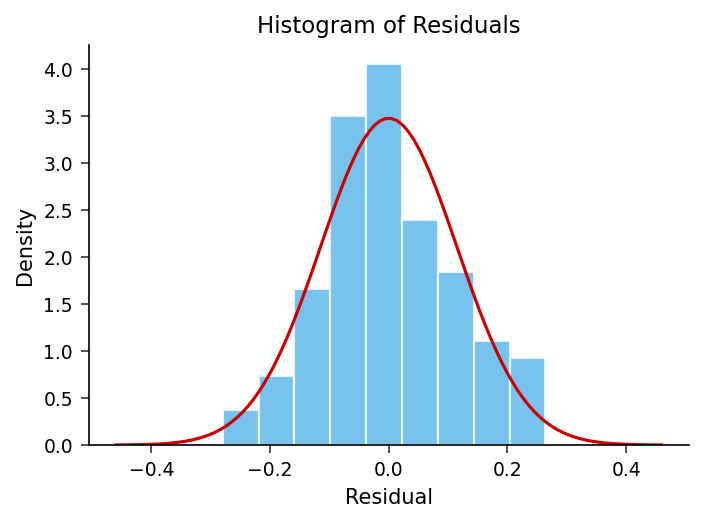

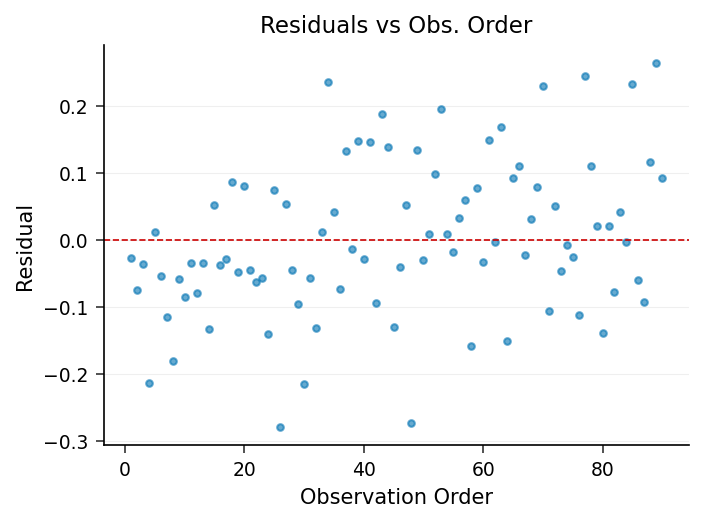

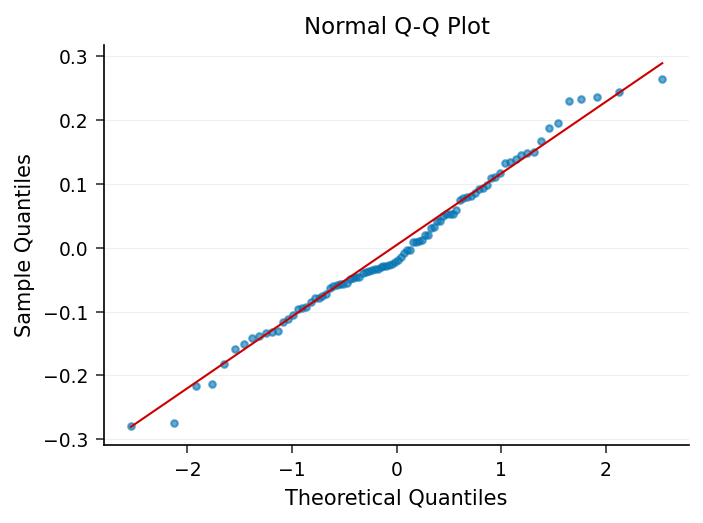

In [6]:
proc mixed data=calibration method=reml covtest cl;
    class part;
    model mass = ;
    random part;
run;

## Interpreting the results

**The balance is certified.** The Average and Range Method reports **%R&R near 1% of total variation** (1.08%) — well inside Barrentine's 10% "excellent" threshold — so almost none of the observed spread comes from the measurement system. By contrast **%PV is essentially 100%** (99.99%): the variation we see is the real difference among the ten certified weights, exactly what the gage is supposed to capture.

**Distinct categories (ndc).** The study yields 130 distinct categories — far above the AIAG minimum of 5 — meaning the balance can reliably separate the reference weights into many resolvable groups, ample resolution for commercial scale audits.

**Charts agree.** The Average (X-bar) chart shows all ten subgroup means falling *outside* the narrow control limits (CL 112.00, UCL 112.13, LCL 111.87) — the desirable signal in a Gage R&R study that the gage detects true part-to-part differences rather than noise. The accompanying Range-chart limits (R-bar 0.386, UCL 0.701) leave every subgroup range in control, confirming repeatability is stable across inspectors.

**Variance components confirm it.** PROC MIXED puts essentially all variance in the `Part` component (146.99, SD 12.1 g) with a near-zero `Residual` (0.0148, SD 0.122 g). The part SD agrees with the range method's implied part SD (PV/6 ≈ 11.3 g) and with the simulated true-mass spread (11.5 g), while the residual SD reproduces the injected 0.12 g equipment noise — so repeatability and reproducibility are statistically and practically negligible. The covariance-parameter tests reject `Part = 0` at p < .0001.

**Decision for the agency.** This measurement system is fit for certifying commercial scales. The remaining lever for tighter assurance is not the inspectors (reproducibility is trivial) but the equipment floor — so routine recalibration of the balance, not added operator training, is the right maintenance focus.